In [250]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------  12.6/12.8 MB 72.1 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 61.8 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [251]:
import itertools
import re
import warnings

import lda
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import pyLDAvis
import seaborn as sns
import spacy
from bs4 import BeautifulSoup
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud


## LDA

In [252]:
# Carga de datos
test = pd.read_csv("data/research-articles/test.csv")
train = pd.read_csv("data/research-articles/train.csv")

display(test.head())
display(train.head())

,ID,TITLE,ABSTRACT
0,20973,Closed-form Marginal Likelihood in Gamma-Poiss...,We present novel understandings of the Gamma...
1,20974,Laboratory mid-IR spectra of equilibrated and ...,Meteorites contain minerals from Solar Syste...
2,20975,Case For Static AMSDU Aggregation in WLANs,Frame aggregation is a mechanism by which mu...
3,20976,The $Gaia$-ESO Survey: the inner disk intermed...,Milky Way open clusters are very diverse in ...
4,20977,Witness-Functions versus Interpretation-Functi...,Proving that a cryptographic protocol is cor...


,ID,TITLE,ABSTRACT,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance
0,1,Reconstructing Subject-Specific Effect Maps,Predictive models allow subject-specific inf...,1,0,0,0,0,0
1,2,Rotation Invariance Neural Network,Rotation invariance and translation invarian...,1,0,0,0,0,0
2,3,Spherical polyharmonics and Poisson kernels fo...,We introduce and develop the notion of spher...,0,0,1,0,0,0
3,4,A finite element approximation for the stochas...,The stochastic Landau--Lifshitz--Gilbert (LL...,0,0,1,0,0,0
4,5,Comparative study of Discrete Wavelet Transfor...,Fourier-transform infra-red (FTIR) spectra o...,1,0,0,1,0,0


In [253]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20972 entries, 0 to 20971
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    20972 non-null  int64 
 1   TITLE                 20972 non-null  object
 2   ABSTRACT              20972 non-null  object
 3   Computer Science      20972 non-null  int64 
 4   Physics               20972 non-null  int64 
 5   Mathematics           20972 non-null  int64 
 6   Statistics            20972 non-null  int64 
 7   Quantitative Biology  20972 non-null  int64 
 8   Quantitative Finance  20972 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 1.4+ MB


In [254]:
train.dtypes

ID                       int64
TITLE                   object
ABSTRACT                object
Computer Science         int64
Physics                  int64
Mathematics              int64
Statistics               int64
Quantitative Biology     int64
Quantitative Finance     int64
dtype: object

In [255]:
documents = list(train.ABSTRACT.values) # utilizaremos solo la columan Abstract como los documentos
print(documents[0]) # como ejemplo imprimimos el primer documento

  Predictive models allow subject-specific inference when analyzing disease
related alterations in neuroimaging data. Given a subject's data, inference can
be made at two levels: global, i.e. identifiying condition presence for the
subject, and local, i.e. detecting condition effect on each individual
measurement extracted from the subject's data. While global inference is widely
used, local inference, which can be used to form subject-specific effect maps,
is rarely used because existing models often yield noisy detections composed of
dispersed isolated islands. In this article, we propose a reconstruction
method, named RSM, to improve subject-specific detections of predictive
modeling approaches and in particular, binary classifiers. RSM specifically
aims to reduce noise due to sampling error associated with using a finite
sample of examples to train classifiers. The proposed method is a wrapper-type
algorithm that can be used with different binary classifiers in a diagnostic
manner,

In [256]:
nltk.download('stopwords')
stop_words_en = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\zeldan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [257]:
## Cargar modelo de spaCy en ingles
nlp = spacy.load("en_core_web_sm")
custom_stops = {
    "research", "paper", "study", "result", "analysis", "method",
    "approach", "system", "data", "based", "user", "model"
}

def remove_html(_text):
    no_html_txt = BeautifulSoup(_text, "html.parser").getText(separator=" ")
    return no_html_txt

def clear_text(_text):
    #Eliminar etiquetas html
    _text = remove_html(_text)

    # Limpieza basica del texto
    ## Eliminar bloques de código entre ```
    _text = re.sub(r"```.*?```", " ", _text, flags=re.DOTALL)

    ##Eliminar etiquetas markdown (#, *, _, >, etc.)
    _text = re.sub(r"[#*_>\-`~]", " ", _text)

    ##Eliminar URLs y direcciones tipo http o www
    _text = re.sub(r"http\S+|www\S+", " ", _text)

    ##Eliminar etiquetas HTML o imágenes ![texto](url)
    _text = re.sub(r"!\[.*?\]\(.*?\)", " ", _text)

    ##quitar números y caracteres no alfabéticos (mantener letras acentuadas)
    texto = re.sub(r"[^a-zA-ZáéíóúñÁÉÍÓÚüÜ\s]", " ", _text)

    ##texto a minusculas para hacer mejores comparaciones
    _text = _text.lower()

    # Eliminacion de stopwords
    doc = nlp(_text) # retorna un objeto con estructura de tokens, lemas, etiquetas (analizado)

    tokens = [] # para guardar palablas sin stopwords
    for word in doc:
        if (
            word.is_alpha and
            not word.is_punct and
            not word.is_space
        ):
            if not word.is_stop and word.lemma_.lower() not in stop_words_en:
                # si la palabra esta formada por letras(no numeros o signos)
                # word.lemma_ -> forma raiz de la palabra
                tokens.append(word.lemma_.lower())

    return " ".join(tokens)

In [258]:
clean_text  = []
for d in documents:
    txt = clear_text(d)
    clean_text.append(txt)

df_clean_docs = pd.DataFrame({
    "texto": clean_text
})
df_clean_docs["num_palabras"] = df_clean_docs["texto"].apply(lambda x: len(x.split()))
print(df_clean_docs.shape)
df_clean_docs.head()

(20972, 2)


,texto,num_palabras
0,predictive model allow subject specific infere...,170
1,rotation invariance translation invariance gre...,43
2,introduce develop notion spherical polyharmoni...,56
3,stochastic landau lifshitz gilbert llg equatio...,65
4,fouri transform infra red ftir spectra sample ...,81


CountVectorizer transforma textos en una matriz documento-término donde cada entrada es el conteo de apariciones de una palabra (término) en un documento.

In [259]:
# ==========================================================
# VECTORIZACIÓN (LDA)
# LDA no acepta texto directamente necesitamos la matriz de frecuencias
# min_df=5: elimina términos que aparecen en menos de 5 documentos
# max_df=0.8: elimina términos que aparecen en más del 80% de los documentos
vectorizer = CountVectorizer(min_df=5, max_df=0.8)
X = vectorizer.fit_transform(clean_text)
vocab = vectorizer.get_feature_names_out()

X.shape, len(vocab)


((20972, 10962), 10962)

In [260]:
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1220706 stored elements and shape (20972, 10962)>

In [261]:
def coherence_score(_topic_words,_texts,_dictionary):
    return CoherenceModel(
        topics=_topic_words,
        texts=_texts,
        dictionary=_dictionary,
        coherence='c_v'
    ).get_coherence()

In [262]:
tokenized_texts = [doc.split() for doc in clean_text]
dictionary = Dictionary(tokenized_texts)

INFO:gensim.corpora.dictionary:adding document #0 to Dictionary<0 unique tokens: []>
INFO:gensim.corpora.dictionary:adding document #10000 to Dictionary<28537 unique tokens: ['accuracy', 'ad', 'adni', 'aim', 'algorithm']...>
INFO:gensim.corpora.dictionary:adding document #20000 to Dictionary<40263 unique tokens: ['accuracy', 'ad', 'adni', 'aim', 'algorithm']...>
INFO:gensim.corpora.dictionary:built Dictionary<41228 unique tokens: ['accuracy', 'ad', 'adni', 'aim', 'algorithm']...> from 20972 documents (total 1781885 corpus positions)
INFO:gensim.utils:Dictionary lifecycle event {'msg': "built Dictionary<41228 unique tokens: ['accuracy', 'ad', 'adni', 'aim', 'algorithm']...> from 20972 documents (total 1781885 corpus positions)", 'datetime': '2025-11-18T14:21:48.520934', 'gensim': '4.4.0', 'python': '3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}


In [263]:
def train_lda_and_get_coherence(num_topics, alpha):
    # Entrenar el modelo
    model = lda.LDA(
        n_topics=num_topics,
        alpha=alpha,
        n_iter=500,
        random_state=0
    )
    model.fit(X)

    # Sacar palabras más importantes de cada tema
    topic_word_matrix = model.topic_word_
    doc_topic_dist = model.doc_topic_
    topic_words = []

    for topic in topic_word_matrix:
        top_indices = np.argsort(topic)[-10:]   # coger 10 palabras con más probabilidad
        top_words = [vocab[i] for i in top_indices]
        topic_words.append(top_words)

    # Calcular coherencia
    score = coherence_score(topic_words, tokenized_texts, dictionary)
    perplexity = model.loglikelihood()

    return score, perplexity, topic_words,topic_word_matrix, doc_topic_dist

In [264]:
results = []
param_grid = {
    "n_topics": [5, 10, 15],
    "alpha": [0.1, 0.5, 1.0]
}

# product() genera todas las combinaciones automáticamente
for n_topics, alpha in itertools.product(param_grid["n_topics"], param_grid["alpha"]):
    print(f"Probando: topics={n_topics}, alpha={alpha}")

    score, perplexity, topic_words, topic_word_matrix, doc_topic_dist = \
        train_lda_and_get_coherence(n_topics, alpha)
    results.append({
        "n_topics": n_topics,
        "alpha": alpha,
        "coherence": score,
        "perplexity": perplexity,
        "topic": topic_words,
        "topic_word_matrix": topic_word_matrix,
        "doc_topic_dist": doc_topic_dist
    })

df_results = pd.DataFrame(results)
df_results

INFO:lda:n_documents: 20972
INFO:lda:vocab_size: 10962
INFO:lda:n_words: 1701859
INFO:lda:n_topics: 5
INFO:lda:n_iter: 500


Probando: topics=5, alpha=0.1


INFO:lda:<0> log likelihood: -16391533
INFO:lda:<10> log likelihood: -14418618
INFO:lda:<20> log likelihood: -13611788
INFO:lda:<30> log likelihood: -13460365
INFO:lda:<40> log likelihood: -13416235
INFO:lda:<50> log likelihood: -13392241
INFO:lda:<60> log likelihood: -13380641
INFO:lda:<70> log likelihood: -13371868
INFO:lda:<80> log likelihood: -13366816
INFO:lda:<90> log likelihood: -13364278
INFO:lda:<100> log likelihood: -13361089
INFO:lda:<110> log likelihood: -13358042
INFO:lda:<120> log likelihood: -13355194
INFO:lda:<130> log likelihood: -13353575
INFO:lda:<140> log likelihood: -13354398
INFO:lda:<150> log likelihood: -13352761
INFO:lda:<160> log likelihood: -13352000
INFO:lda:<170> log likelihood: -13349839
INFO:lda:<180> log likelihood: -13352219
INFO:lda:<190> log likelihood: -13349863
INFO:lda:<200> log likelihood: -13351415
INFO:lda:<210> log likelihood: -13349358
INFO:lda:<220> log likelihood: -13349902
INFO:lda:<230> log likelihood: -13347998
INFO:lda:<240> log likeliho

Probando: topics=5, alpha=0.5


INFO:lda:<0> log likelihood: -16290315
INFO:lda:<10> log likelihood: -14485984
INFO:lda:<20> log likelihood: -13731980
INFO:lda:<30> log likelihood: -13626234
INFO:lda:<40> log likelihood: -13582484
INFO:lda:<50> log likelihood: -13557601
INFO:lda:<60> log likelihood: -13543638
INFO:lda:<70> log likelihood: -13532171
INFO:lda:<80> log likelihood: -13525252
INFO:lda:<90> log likelihood: -13519813
INFO:lda:<100> log likelihood: -13517673
INFO:lda:<110> log likelihood: -13515279
INFO:lda:<120> log likelihood: -13511169
INFO:lda:<130> log likelihood: -13514119
INFO:lda:<140> log likelihood: -13513027
INFO:lda:<150> log likelihood: -13511030
INFO:lda:<160> log likelihood: -13511335
INFO:lda:<170> log likelihood: -13509309
INFO:lda:<180> log likelihood: -13511983
INFO:lda:<190> log likelihood: -13508714
INFO:lda:<200> log likelihood: -13509813
INFO:lda:<210> log likelihood: -13509002
INFO:lda:<220> log likelihood: -13510112
INFO:lda:<230> log likelihood: -13508998
INFO:lda:<240> log likeliho

...

Probando: topics=15, alpha=0.5


INFO:lda:<0> log likelihood: -18636344
INFO:lda:<10> log likelihood: -15335226
INFO:lda:<20> log likelihood: -14424414
INFO:lda:<30> log likelihood: -14175016
INFO:lda:<40> log likelihood: -14061799
INFO:lda:<50> log likelihood: -13998924
INFO:lda:<60> log likelihood: -13957586
INFO:lda:<70> log likelihood: -13932354
INFO:lda:<80> log likelihood: -13911750
INFO:lda:<90> log likelihood: -13898856
INFO:lda:<100> log likelihood: -13885569
INFO:lda:<110> log likelihood: -13875251
INFO:lda:<120> log likelihood: -13869285
INFO:lda:<130> log likelihood: -13859796
INFO:lda:<140> log likelihood: -13853747
INFO:lda:<150> log likelihood: -13851688
INFO:lda:<160> log likelihood: -13847780
INFO:lda:<170> log likelihood: -13844873
INFO:lda:<180> log likelihood: -13840975
INFO:lda:<190> log likelihood: -13835975
INFO:lda:<200> log likelihood: -13834664
INFO:lda:<210> log likelihood: -13834578
INFO:lda:<220> log likelihood: -13832221
INFO:lda:<230> log likelihood: -13829566
INFO:lda:<240> log likeliho

Probando: topics=15, alpha=1.0


INFO:lda:<0> log likelihood: -18528014
INFO:lda:<10> log likelihood: -15553188
INFO:lda:<20> log likelihood: -14501355
INFO:lda:<30> log likelihood: -14239945
INFO:lda:<40> log likelihood: -14133426
INFO:lda:<50> log likelihood: -14077188
INFO:lda:<60> log likelihood: -14041183
INFO:lda:<70> log likelihood: -14011674
INFO:lda:<80> log likelihood: -13994845
INFO:lda:<90> log likelihood: -13980700
INFO:lda:<100> log likelihood: -13969120
INFO:lda:<110> log likelihood: -13963784
INFO:lda:<120> log likelihood: -13955991
INFO:lda:<130> log likelihood: -13952723
INFO:lda:<140> log likelihood: -13946646
INFO:lda:<150> log likelihood: -13942131
INFO:lda:<160> log likelihood: -13938232
INFO:lda:<170> log likelihood: -13934936
INFO:lda:<180> log likelihood: -13931531
INFO:lda:<190> log likelihood: -13930133
INFO:lda:<200> log likelihood: -13929324
INFO:lda:<210> log likelihood: -13932296
INFO:lda:<220> log likelihood: -13928370
INFO:lda:<230> log likelihood: -13927938
INFO:lda:<240> log likeliho

,n_topics,alpha,coherence,perplexity,topic,topic_word_matrix,doc_topic_dist
0,5,0.1,0.465943,-1.334501e+07,"[[study, paper, theory, graph, prove, group, f...","[[3.918485777972837e-08, 3.918485777972837e-08...","[[0.0005934718100890209, 0.042136498516320474,..."
1,5,0.5,0.459624,-1.350962e+07,"[[study, paper, theory, group, prove, function...","[[3.6695682921698496e-08, 3.6695682921698496e-...","[[0.002932551319648094, 0.04398826979472141, 0..."
2,5,1.0,0.467113,-1.357758e+07,"[[set, study, theory, prove, group, function, ...","[[3.5313151020003846e-08, 3.5313151020003846e-...","[[0.011560693641618497, 0.05202312138728324, 0..."
3,10,0.1,0.522345,-1.345402e+07,"[[temperature, model, magnetic, quantum, spin,...","[[3.575962779986114e-05, 4.464373008721741e-08...","[[0.01834319526627219, 0.3260355029585799, 0.0..."
4,10,0.5,0.518248,-1.369248e+07,"[[condition, result, order, flow, model, time,...","[[6.613292108716048e-08, 6.613292108716048e-08...","[[0.014450867052023121, 0.3439306358381503, 0...."
5,10,1.0,0.541757,-1.378265e+07,"[[non, result, order, flow, condition, time, f...","[[6.486404301991319e-08, 6.486404301991319e-08...","[[0.016853932584269662, 0.0056179775280898875,..."
6,15,0.1,0.536372,-1.354064e+07,"[[paper, condition, system, prove, operator, r...","[[8.13328039110173e-08, 8.13328039110173e-08, ...","[[0.0005899705014749264, 0.0005899705014749264..."
7,15,0.5,0.536402,-1.382957e+07,"[[class, manifold, finite, algebra, function, ...","[[8.236986673051428e-08, 8.236986673051428e-08...","[[0.002849002849002849, 0.002849002849002849, ..."
8,15,1.0,0.537380,-1.391940e+07,"[[point, obtain, result, order, condition, ope...","[[8.956831832438528e-08, 8.956831832438528e-08...","[[0.01092896174863388, 0.01092896174863388, 0...."


In [265]:
best_row = df_results.loc[df_results["coherence"].idxmax()]
best_row

n_topics                                                            10
alpha                                                              1.0
coherence                                                     0.541757
perplexity                                            -13782651.870167
topic                [[non, result, order, flow, condition, time, f...
topic_word_matrix    [[6.486404301991319e-08, 6.486404301991319e-08...
doc_topic_dist       [[0.016853932584269662, 0.0056179775280898875,...
Name: 5, dtype: object

In [266]:
best_topic_words = best_row["topic"]
print(type(best_topic_words))
best_topic_words

<class 'list'>


[['non',
  'result',
  'order',
  'flow',
  'condition',
  'time',
  'function',
  'solution',
  'system',
  'equation'],
 ['performance',
  'power',
  'environment',
  'agent',
  'design',
  'base',
  'propose',
  'time',
  'control',
  'system'],
 ['interaction',
  'transition',
  'temperature',
  'magnetic',
  'energy',
  'quantum',
  'spin',
  'field',
  'state',
  'phase'],
 ['propose',
  'estimation',
  'parameter',
  'random',
  'estimate',
  'sample',
  'method',
  'datum',
  'distribution',
  'model'],
 ['low',
  'line',
  'cluster',
  'large',
  'observation',
  'galaxy',
  'find',
  'high',
  'mass',
  'star'],
 ['number',
  'theory',
  'give',
  'class',
  'set',
  'result',
  'prove',
  'space',
  'group',
  'graph'],
 ['task',
  'deep',
  'neural',
  'image',
  'propose',
  'method',
  'learning',
  'learn',
  'model',
  'network'],
 ['node',
  'pattern',
  'individual',
  'analysis',
  'social',
  'different',
  'time',
  'study',
  'model',
  'network'],
 ['research',
 

In [267]:
df_topics = pd.DataFrame({
    "Topic": [f"Tema {i}" for i in range(len(best_topic_words))],
    "Words": [", ".join(words) for words in best_topic_words]
})
df_topics

,Topic,Words
0,Tema 0,"non, result, order, flow, condition, time, fun..."
1,Tema 1,"performance, power, environment, agent, design..."
2,Tema 2,"interaction, transition, temperature, magnetic..."
3,Tema 3,"propose, estimation, parameter, random, estima..."
4,Tema 4,"low, line, cluster, large, observation, galaxy..."
5,Tema 5,"number, theory, give, class, set, result, prov..."
6,Tema 6,"task, deep, neural, image, propose, method, le..."
7,Tema 7,"node, pattern, individual, analysis, social, d..."
8,Tema 8,"research, present, provide, base, code, applic..."
9,Tema 9,"solve, number, function, matrix, time, optimiz..."


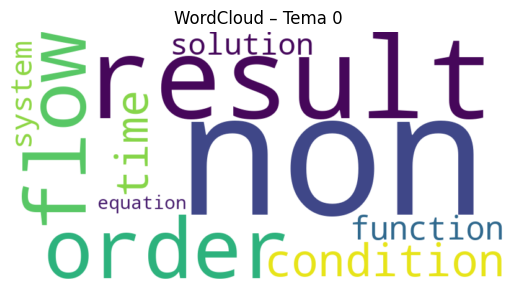

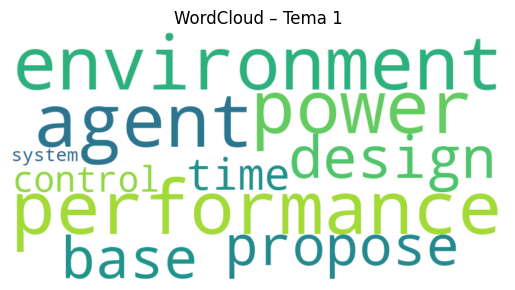

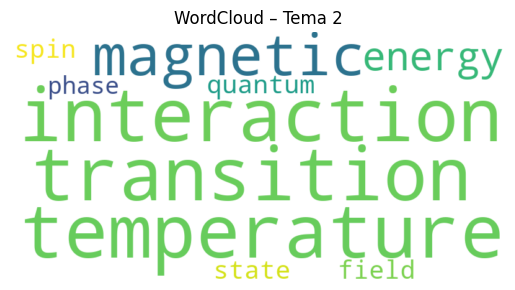

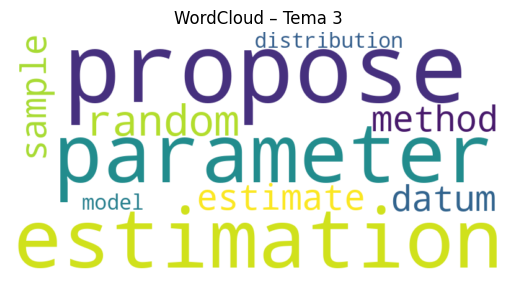

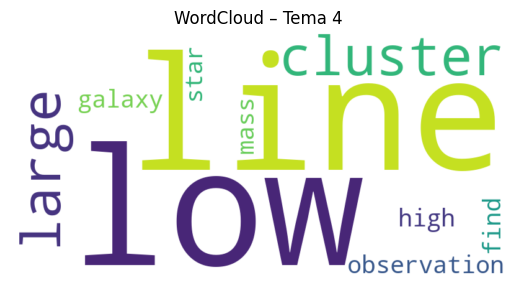

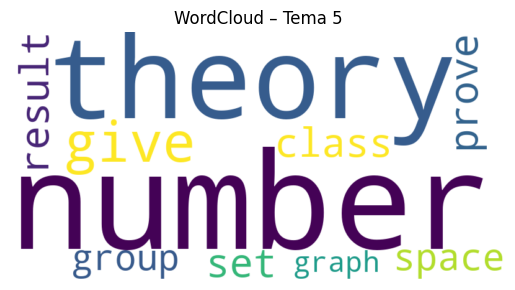

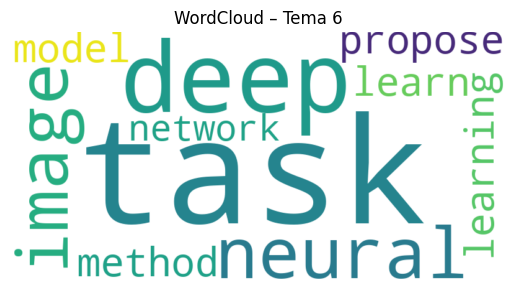

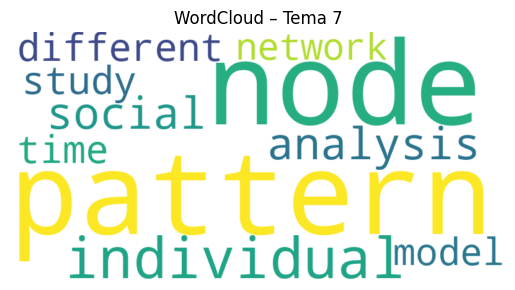

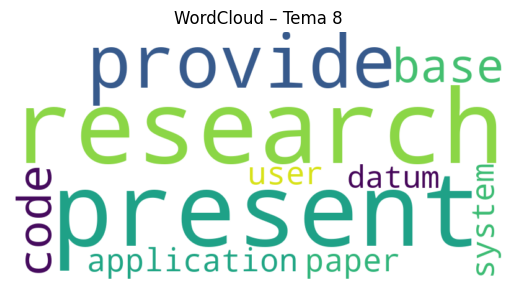

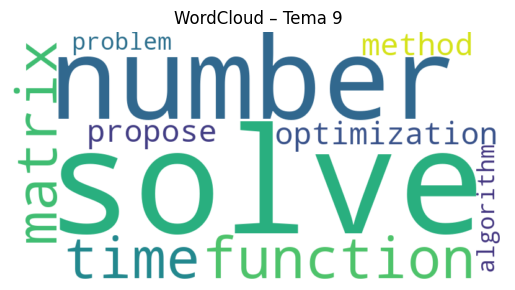

In [268]:
# Filtrar advertencias específicas
warnings.filterwarnings("ignore", category=DeprecationWarning, module="matplotlib")
for i, words in enumerate(best_topic_words):
    text = " ".join(words)
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure()
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud – Tema {i}")
    plt.show()

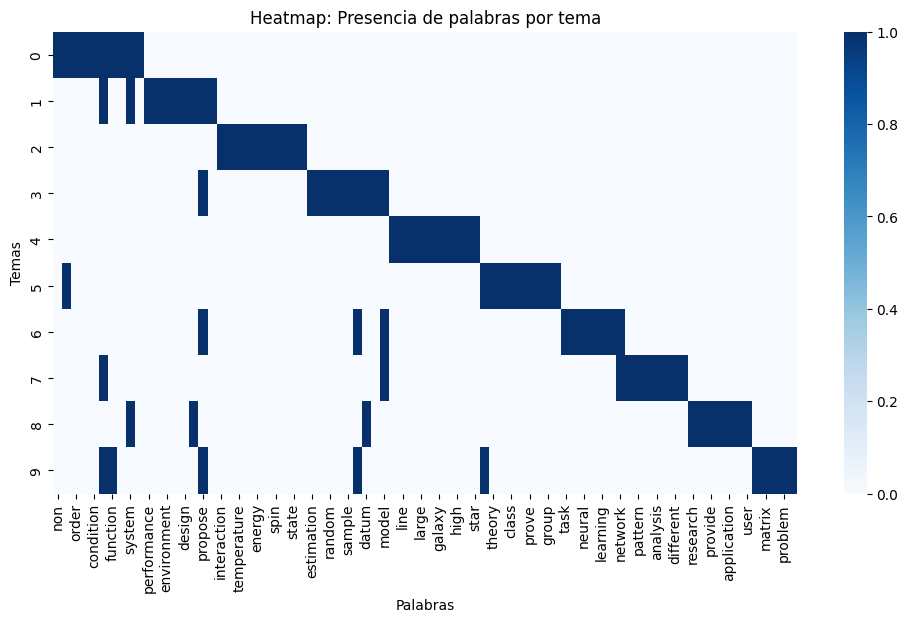

In [269]:
# Convertimos la lista en una matriz simple
# 1 = palabra presente en el top del tema
data = []

for words in best_topic_words:
    row = {w:1 for w in words}
    data.append(row)

df_heat = pd.DataFrame(data).fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(df_heat, cmap="Blues", annot=False)
plt.title("Heatmap: Presencia de palabras por tema")
plt.xlabel("Palabras")
plt.ylabel("Temas")
plt.show()

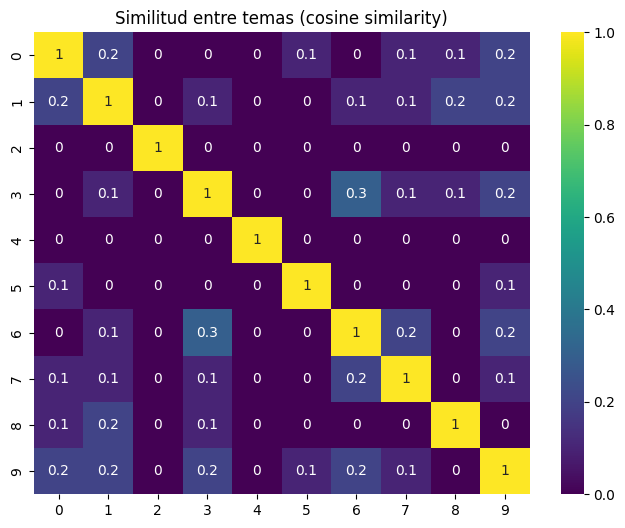

In [270]:
# Creamos vectores binarios de 0/1 para cada palabra
vocab = sorted(list({w for words in best_topic_words for w in words}))

topic_vectors = []
for words in best_topic_words:
    vec = [1 if v in words else 0 for v in vocab]
    topic_vectors.append(vec)

topic_vectors = np.array(topic_vectors)

# Similaridad coseno
from sklearn.metrics.pairwise import cosine_similarity
sim_matrix = cosine_similarity(topic_vectors)

plt.figure(figsize=(8,6))
sns.heatmap(sim_matrix, annot=True, cmap="viridis")
plt.title("Similitud entre temas (cosine similarity)")
plt.show()

In [271]:
# Matriz tema-palabra (tópicos x vocabulario)
topic_term_dists = best_row['topic_word_matrix']
doc_topic_dists = best_row['doc_topic_dist']

doc_lengths = np.asarray(X.sum(axis=1)).ravel()
term_frequency = np.asarray(X.sum(axis=0)).ravel()
vocab = vectorizer.get_feature_names_out()

print(topic_term_dists.shape[1], len(vocab))
print(len(term_frequency), len(vocab))

10962 10962
10962 10962


In [272]:
vis = pyLDAvis.prepare(
    topic_term_dists,
    doc_topic_dists,
    doc_lengths,
    vocab,
    term_frequency,
    sort_topics=False
)

pyLDAvis.display(vis)